In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, ceil, log2, pi
import time

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT

import warnings
warnings.filterwarnings('ignore')

## **CLASSICAL HELPER FUNCTION**

In [121]:
def is_prime(n):
    #cek n salah satunya prima
    if n < 2: return False
    for i in range(2, int(n**0.5)+1):
        if n % i == 0: return False
    return True

def is_semiprime(n):
    #cek n keduanya prima
    for i in range(2, int(n**0.5)+1):
        if n % i == 0 and is_prime(i) and is_prime(n//i):
            return False
        return False

def mod_exp_classical(a, power, N):
    #classical modular a^power mod N
    return pow(int(a), int(power), int(N))

def find_period_classical(a, N):
    #classic menemukan periode r dari a^r ≡ 1 (mod N)
    r = 1
    val = a % N
    while val != 1:
        val = (val * a) % N
        r += 1
        if r > N:
            return None
    return r

def get_factors_from_period(a, r, N):
    #ekstrak faktor N dengan periode r dan a
    if r is None or r % 2 != 0:
        return None, None
    x = pow(int(a), r//2, N)
    if x == N - 1:
        return None, None
    f1 =  gcd(x + 1, N)
    f2 = gcd(x - 1, N)
    if f1 not in [1, N] and f2 not in [1, N]:
        return f1, f2
    return None, None

def continued_fraction_period(measured, t, N):
    #untuk mengektrak periode r dari perhitungan
    if measured == 0:
        return None
    frac = Fraction(measured, 2**t).limit_denominator(N)
    return frac.denominator

## **MEMBANGUN QUANTUM CIRCUIT**

### ***1. EXACT QFT***

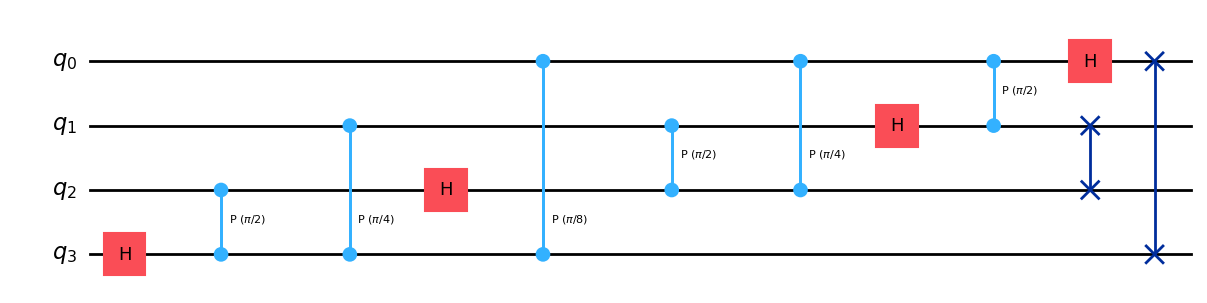

In [122]:
def build_exact_qft(n_qubits, inverse=False):
    #Build exact QFT circuit on n_qubits. O(n^2) gates
    qc = QuantumCircuit(n_qubits, name= 'QFT' if not inverse else 'IQFT')

    if not inverse:
        for i in range(n_qubits -1, -1, -1):
            qc.h(i)
            for j in range(i -1, -1, -1):
                angle = np.pi/(2**(i-j))
                qc.cp(angle, j, i)
        
        #swap qubits
        for i in range(n_qubits//2):
            qc.swap(i, n_qubits - 1 -i)
    
    else:
        #inverse QFT
        for i in range (n_qubits//2):
            qc.swap(i, n_qubits - 1 -i)
        for i in range(n_qubits):
            for j in range(i - 1, -1, -1):
                angle = np.pi/ (2 ** (i-j))
                qc.cp(angle, j, i)
            qc.h(i)
    return qc

build_exact_qft(4).draw('mpl')


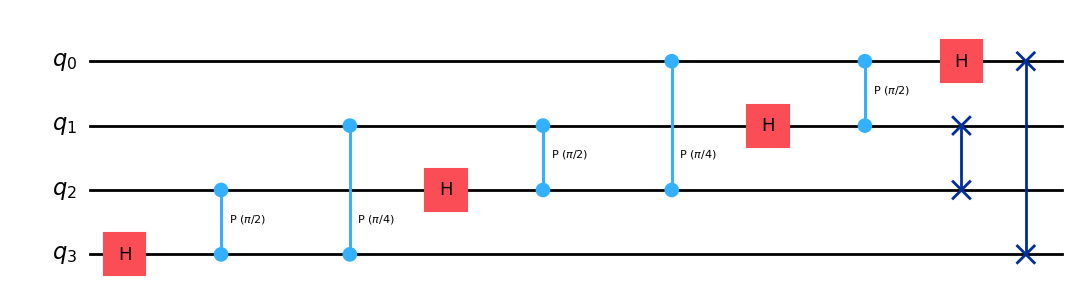

In [123]:
def build_approx_qft(n_qubits, kmax=None, inverse=False):
    #Build approximate QFT circuit. 
    #Reduces gates from O(n^2) to O(n log n).
    #Prunes controlled-phase gates where rotation>kmax threshold
    if kmax is None:
        kmax = int(np.log2(n_qubits)) if n_qubits > 1 else 1

    qc = QuantumCircuit(n_qubits, name=f'AQFT(k={kmax})' if not inverse else f'AQFT†(k={kmax})')

    if not inverse:
        #listing 1
        i = n_qubits - 1
        while i >= 0:
            qc.h(i)
            j = i - 1
            while j >= 0 and (i - j) <= kmax:
                angle = np.pi / (2**(i - j))
                if angle > 0:
                    qc.cp(angle, j, i)
                j -= 1
            i -= 1
        #swap
        for i in range(n_qubits // 2):
            qc.swap(i, n_qubits - 1 - i)
    
    else:
        #inverse approximate QFT
        for i in range(n_qubits // 2):
            qc.swap(i, n_qubits - 1 - i)
        i = 0
        while i < n_qubits:
            j = i - 1
            while j >= 0 and (i - j) <= kmax:
                angle = -np.pi / (2**(i - j))
                if angle != 0:
                    qc.cp(angle, j, i)
                j -= 1
            qc.h(i)
            i += 1
    
    return qc

build_approx_qft(4, kmax=2).draw('mpl')

### ***2. QFT BASED ADDER (DRAPPER ADDER)***

adds classical integer a to quantum register. Assumes register os a;ready in QFT basis. Based on Draper's addition on a quantum computer.

In [124]:
def qft_add(n, a, use_approx=False, kmax=None):
    qc = QuantumCircuit(n, name=f'Add({a})')

    if kmax is None:
        kmax = n if not use_approx else int(np.log2(n)) if n > 1 else 1

    for i in range(n):
        for j in range(i + 1):
            if (i - j) < kmax or not use_approx:
                #phase contribution of bit j of a to qubit i
                if (a >> j) & i:
                    angle = 2 * np.pi / (2** (i - j + 1))
                    qc.p(angle, i)
    return qc 

#qft_add(4, 5, kmax=2).draw('mpl')

In [125]:
def qft_add_mod_N(n, a, N, use_approx=False):
    #modular QFT adder is for compute (x + a) mod N in QFT basis.
    #Simplified version using ancilla-free approach
    qc = QuantumCircuit(n + 1, name=f'AddMod({a}, {N})')

    #This is a simplified placeholder for the full Beauregard circuit
    #Full implementation would include overflow detection
    for i in range(n):
        for j in range(i + 1):
            if (a >> j) & 1:
                angle = 2 * np.pi / (2 ** (i - j +1))
                qc.p(angle, i)
    return qc

### ***3. CONTROLLED MODULAR EXPONENTIATION (simplified)***

In [126]:
def build_ctrl_U(a, power, N, n_qubits):
    #Build the unitary U^(2^power) which maps |y> -> |a^(2^power) * y mod N>.
    #This is the controlled modular multiplication gate.
    #Uses matrix representation for small N (simulation purposes)

    dim = 2 ** n_qubits
    a_pow = pow(int(a), int(2**power), int(N))

    U_base = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        if y < N:
            new_y = (a_pow * y) % N
            U_base[new_y, y] = 1.0
        else:
            U_base[y, y] = 1.0      #identity untuk state >= N
    
    total_dim = 2 * dim
    ctrl_U = np.zeros((total_dim, total_dim), dtype=complex)

    for w in range(dim):
        ctrl_U[2*w, 2*w] = 1.0      #ctrl = 0: |0,w> → |0,w>
        for w2 in range(dim):   #ctrl = 1: |1,w> → |1, U_base*w>
            if U_base[w2, w] != 0:
                ctrl_U[1 + 2*w2, 1 + 2*w] = U_base[w2,w]
                        
    return ctrl_U

### ***4. FULL SHOR'S ALGORITHM CIRCUIT***

Circuit uses:

- t = 2L qubits for upper (counting) register [QPE register]

- L qubits  for lower (work) register where 
$$ L = ceil(log2(N)) $$
    
Based on Beauregard's 2L+3 qubit approach.

In [127]:
def build_shors_circuit(N, a, use_approx=False, kmax=None):
    #N = number to factor
    #a = base(random, 1 < a < N, gcd(a,N) = 1)
    #use_approx = use approximate QFT
    #kmax = threshold for approximate QFT
    
    L = ceil(log2(N+1))
    t = 2 * L               #number of counting qubits
    n = L                   #work register size

    if kmax is None:
        kmax = int(log2(t)) if t > 1 else 1

    #register
    counting = QuantumRegister(t, name='count')
    work = QuantumRegister(n, name='work')
    cbits = ClassicalRegister(t, name='c')

    qc = QuantumCircuit(counting, work, cbits)

    #STAGE 1
    qc.h(counting)      #inisialisasi counting register in superposition
    qc.x(work[0])       #inisialisasi work register ke |1>
    qc.barrier(label='stage 1')

    #STAGE 2
    #apply gerbang controlled U^(2^j)
    for j in range(t):
        ctrl_matrix = build_ctrl_U(a, j, N, n)
        #build circuit dengan control qubit prepended
        qubits  = [counting[j]] + list(work)
        qc.unitary(ctrl_matrix, qubits, label=f'CU^{2**j}')

    qc.barrier(label='stage 2')

    #STAGE 3
    #apply inverse QFT to counting register
    iqft = build_approx_qft(t, kmax=kmax, inverse=True) if use_approx else build_exact_qft(t, inverse=True)
    qc.compose(iqft, qubits=list(counting), inplace=True)

    #STAGE 4
    qc.measure(counting, cbits)
    return qc, t, L

coba simulasi yang sama di paper, dengan:

N = 15

a = 2

In [128]:
print("Building circuit for N=15, a=2 (Exact QFT)...")
qc_test, t_test, L_test = build_shors_circuit(15, 2, use_approx=False)
print(f"  L={L_test}, t={t_test} counting qubits")
print(f"  Total qubits: {qc_test.num_qubits}")
print(f"  Total gates: {qc_test.size()}")
print(f"  Circuit depth: {qc_test.depth()}")

Building circuit for N=15, a=2 (Exact QFT)...
  L=4, t=8 counting qubits
  Total qubits: 12
  Total gates: 65
  Circuit depth: 47


### ***5. SIMULATION RUNNER***

Run Shor's algorithm simulation and return:

    - counts: measurement results
    - prob_spectrum: probability for each measured state
    - timing: dict with transpile_time, exec_time, total_time
    - correctness: fraction of shots yielding a valid factor

In [129]:
def run_shors_simulation(N, a, shots=1024, use_approx=False, kmax=None):
    backend = AerSimulator()

    #build circuit
    t0_total = time.time()
    qc, t, L = build_shors_circuit(N, a, use_approx=use_approx, kmax=kmax)

    t1 = time.time()
    result = backend.run(qc, shots=shots).result()
    exec_time = time.time() - t1
    total_time = time.time() - t0_total

    counts = result.get_counts()

    prob = np.zeros(2**t)
    for b, c in counts.items():
        prob[int(b, 2)] = c/shots

    correct = sum(
        c for b, c in counts.items()
        if get_factors_from_period(
            a, continued_fraction_period(int(b, 2), t, N), N
        )[0] is not None
    )

    timing = {'exec_time': exec_time, 'total_time': total_time, 'transpile_time': 0}
    return counts, prob, timing, correct / shots * 100, t

### ***6. CORRECTNESS ANALYSIS (MENAMPILKAN PROBABILITY SPECTRUM)***

In [130]:
def compute_theoretical_distribution(a, N, t):
    #compute the theoritical probability distribution for QPE
    #peaks occur at x = 2^r * (s/r)
    #for s = [0, r-1]

    r = find_period_classical(a, N)
    if r is None: 
        return np.zeros(2**t)
    
    n_states = 2**t
    theo = np.zeros(n_states)

    for s in range(r):
        peak = round(n_states * s/r) % n_states
        theo[peak] += 1.0 / r
    
    return theo

In [135]:
def plot_probability_spectrum(N_list, a_list, shots=1024, figsize=(14, 10)):
    configs = [
        (N_list[0], a_list[0], False, f'N={N_list[0]}, a={a_list[0]}, exact QFT'),
        (N_list[1], a_list[1], False, f'N={N_list[1]}, a={a_list[1]}, exact QFT'),
        (N_list[0], a_list[0], True,  f'N={N_list[0]}, a={a_list[0]}, approximate QFT'),
        (N_list[1], a_list[1], True,  f'N={N_list[1]}, a={a_list[1]}, approximate QFT'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    for ax, (N, a, approx, title) in zip(axes.flatten(), configs):
        print(f"  Simulating: {title} ...")
        _, prob, _, correctness, t = run_shors_simulation(
            N, a, shots=shots, use_approx=approx
        )

        theo = compute_theoretical_distribution(a, N, t)

        x = np.arange(len(prob))
        ax.bar(x, prob, color='blue', alpha=0.7, label='Simulated', width=2.0)
        ax.plot(x, theo, color='red', linewidth=1.2, label='Theoretical')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('State')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        print(f"    Correctness: {correctness:.2f}%")
    plt.suptitle("Probability Spectrum — Figure 3", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure3.png', dpi=150, bbox_inches='tight')
    plt.show()


  Simulating: N=15, a=2, exact QFT ...
    Correctness: 48.83%
  Simulating: N=111, a=2, exact QFT ...
    Correctness: 34.38%
  Simulating: N=15, a=2, approximate QFT ...
    Correctness: 48.83%
  Simulating: N=111, a=2, approximate QFT ...
    Correctness: 29.49%


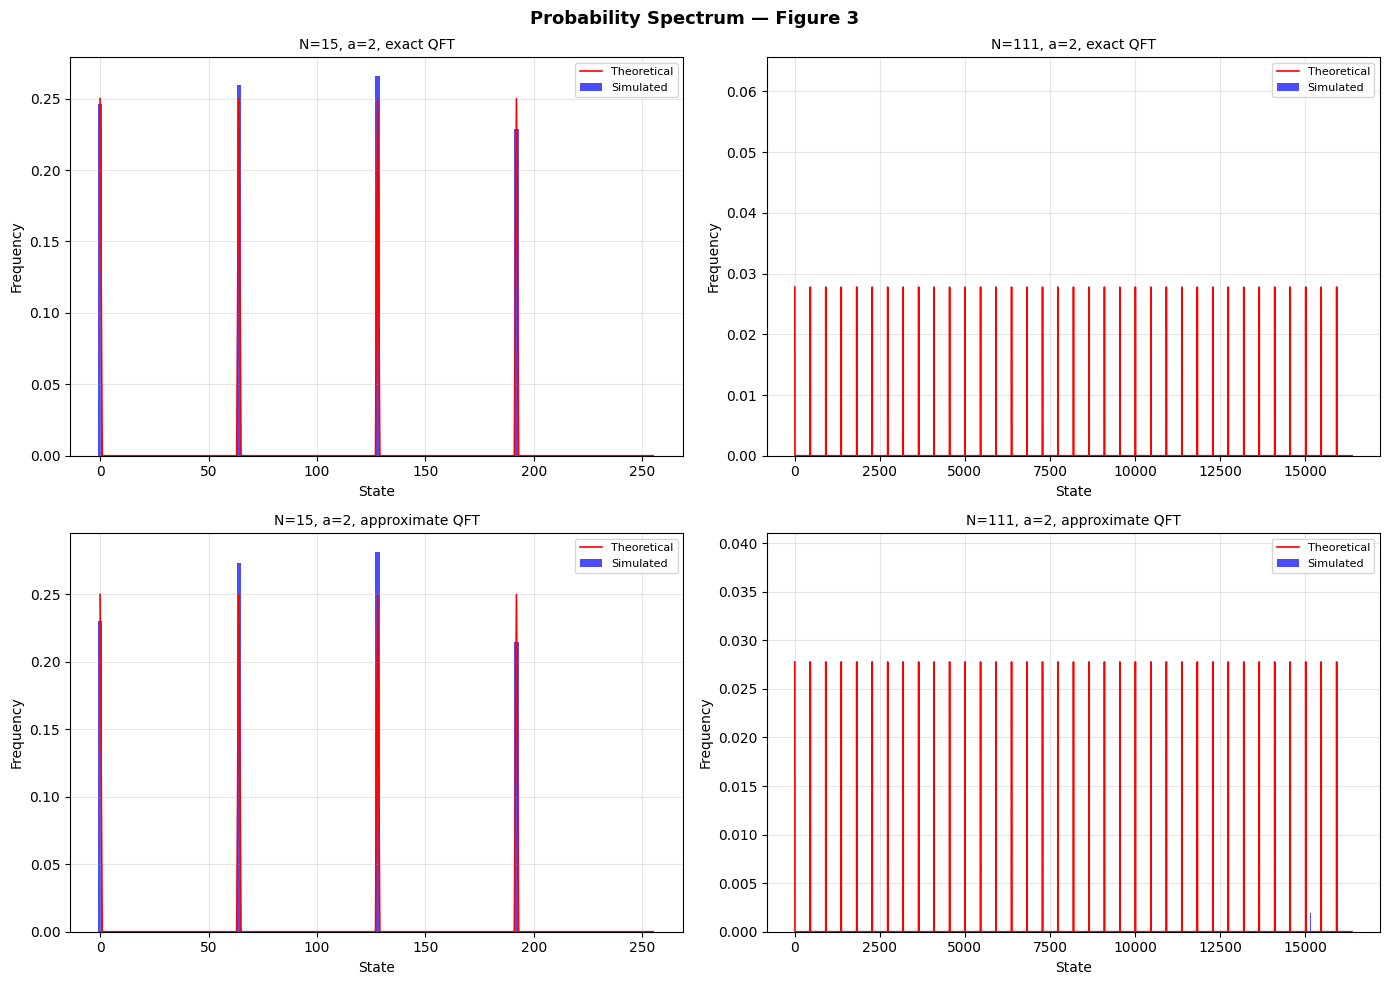

In [136]:
plot_probability_spectrum([15, 111], [2, 2], shots=512)